## Load Dataset

Load the bike-sharing rental dataset from 'Dataset.csv' into a pandas DataFrame. Display the first few rows to confirm successful loading.


In [ ]:
_import pandas as pd

df = pd.read_csv('Dataset.csv')
print("DataFrame loaded successfully. Displaying the first 5 rows:")
df.head()

DataFrame loaded successfully. Displaying the first 5 rows:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


## Initial Data Description and Structure

I will perform the initial exploratory data analysis steps: display DataFrame information, descriptive statistics, convert 'dteday' to datetime, and identify unique values for categorical columns as instructed.



In [ ]:
print("DataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
df.describe()

print("\nConverting 'dteday' to datetime objects...")
df['dteday'] = pd.to_datetime(df['dteday'], format='%d-%m-%Y')
print("'dteday' column converted. Checking info again:")
df.info()

categorical_cols = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']

print("\nUnique values for categorical columns:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    print(f"Unique values: {df[col].unique()}")

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   instant     17379 non-null  int64 
 1   dteday      17379 non-null  object
 2   season      17379 non-null  object
 3   yr          17379 non-null  object
 4   mnth        17379 non-null  object
 5   hr          17379 non-null  int64 
 6   holiday     17379 non-null  object
 7   weekday     17379 non-null  int64 
 8   workingday  17379 non-null  object
 9   weathersit  17379 non-null  object
 10  temp        17379 non-null  object
 11  atemp       17379 non-null  object
 12  hum         17379 non-null  object
 13  windspeed   17379 non-null  object
 14  casual      17379 non-null  object
 15  registered  17379 non-null  object
 16  cnt         17379 non-null  int64 
dtypes: int64(4), object(13)
memory usage: 2.3+ MB

Descriptive Statistics:

Converting 'dteday' to datetime object

## Data Cleaning - Missing Values and Duplicates

Check for any missing values across all columns and determine the best strategy for handling them (e.g., imputation or removal). Also, identify and handle any duplicate records in the dataset.


The first step is to replace all occurrences of '?' with `pd.NA` to standardize missing value representation across the DataFrame, as indicated by the previous output from `df.info()` and `df.unique()`. Then, I will convert the specified columns to a numeric data type, coercing errors to `pd.NA` for robust handling of non-numeric entries.



In [ ]:
import numpy as np

# Step 1: Replace '?' with pd.NA
print("Replacing '?' with pd.NA across the DataFrame...")
df.replace('?', pd.NA, inplace=True)
print("Replacement complete.")

# Step 2: Convert specified columns to numeric, coercing errors
print("Converting 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered' to numeric...")
for col in ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
print("Conversion complete. Displaying updated DataFrame info:")
df.info()

Replacing '?' with pd.NA across the DataFrame...
Replacement complete.
Converting 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered' to numeric...
Conversion complete. Displaying updated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17373 non-null  object        
 3   yr          17378 non-null  object        
 4   mnth        17378 non-null  object        
 5   hr          17379 non-null  int64         
 6   holiday     17378 non-null  object        
 7   weekday     17379 non-null  int64         
 8   workingday  17374 non-null  object        
 9   weathersit  17375 non-null  object        
 10  temp        17368 non-null  float64       
 11  atemp       17373 non-null  float64       
 12  hu

Now that '?' values have been standardized to `pd.NA` and relevant columns converted to numeric, I will proceed with checking for missing values, imputing numerical columns with their medians, and categorical columns with their modes. Finally, I'll verify the imputation by checking for missing values again and then handle duplicate rows.



In [ ]:
print("Checking for missing values after initial conversion:")
print(df.isnull().sum())

# Step 4: Impute numerical columns with median
print("\nImputing numerical columns with their median...")
numerical_cols_to_impute = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered']
for col in numerical_cols_to_impute:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  - Imputed '{col}' with median: {median_val}")

# Step 5: Impute categorical columns with mode
print("\nImputing categorical columns with their mode...")
categorical_cols_to_impute = ['season', 'yr', 'mnth', 'holiday', 'workingday', 'weathersit']
for col in categorical_cols_to_impute:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0] # mode() can return multiple values, take the first
        df[col].fillna(mode_val, inplace=True)
        print(f"  - Imputed '{col}' with mode: {mode_val}")

# Step 6: Verify that all missing values have been handled
print("\nVerifying missing values after imputation:")
print(df.isnull().sum())

# Step 7: Check for duplicate rows
print("\nChecking for duplicate rows...")
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates_count}")

# Step 8: Remove identified duplicate rows
if duplicates_count > 0:
    print("\nRemoving duplicate rows...")
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
else:
    print("\nNo duplicate rows to remove.")

# Step 9: Confirm duplicate rows removal and display new DataFrame shape
print("\nConfirming duplicate rows removal and displaying new DataFrame shape:")
print(f"New DataFrame shape: {df.shape}")
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")

Checking for missing values after initial conversion:
instant        0
dteday         0
season         6
yr             1
mnth           1
hr             0
holiday        1
weekday        0
workingday     5
weathersit     4
temp          11
atemp          6
hum            6
windspeed      5
casual         1
registered     1
cnt            0
dtype: int64

Imputing numerical columns with their median...
  - Imputed 'temp' with median: 0.5
  - Imputed 'atemp' with median: 0.4848
  - Imputed 'hum' with median: 0.63
  - Imputed 'windspeed' with median: 0.194
  - Imputed 'casual' with median: 17.0
  - Imputed 'registered' with median: 115.0

Imputing categorical columns with their mode...
  - Imputed 'season' with mode: fall
  - Imputed 'yr' with mode: 2012
  - Imputed 'mnth' with mode: 5
  - Imputed 'holiday' with mode: No
  - Imputed 'workingday' with mode: Working Day
  - Imputed 'weathersit' with mode: Clear

Verifying missing values after imputation:
instant       0
dteday        0
seas

/tmp/ipython-input-2531487796.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipython-input-2531487796.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

The previous code generated `FutureWarning` due to the use of `inplace=True` with `fillna` on a DataFrame slice. To resolve this, I will modify the imputation steps to assign the result of `fillna` back to the DataFrame column directly, ensuring the operation is performed on the original object and avoiding the warning.



In [ ]:
print("Checking for missing values after initial conversion:")
print(df.isnull().sum())

# Step 4: Impute numerical columns with median
print("\nImputing numerical columns with their median...")
numerical_cols_to_impute = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered']
for col in numerical_cols_to_impute:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val) # Fix: Assign back directly
        print(f"  - Imputed '{col}' with median: {median_val}")

# Step 5: Impute categorical columns with mode
print("\nImputing categorical columns with their mode...")
categorical_cols_to_impute = ['season', 'yr', 'mnth', 'holiday', 'workingday', 'weathersit']
for col in categorical_cols_to_impute:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0] # mode() can return multiple values, take the first
        df[col] = df[col].fillna(mode_val) # Fix: Assign back directly
        print(f"  - Imputed '{col}' with mode: {mode_val}")

# Step 6: Verify that all missing values have been handled
print("\nVerifying missing values after imputation:")
print(df.isnull().sum())

# Step 7: Check for duplicate rows
print("\nChecking for duplicate rows...")
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates_count}")

# Step 8: Remove identified duplicate rows
if duplicates_count > 0:
    print("\nRemoving duplicate rows...")
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
else:
    print("\nNo duplicate rows to remove.")

# Step 9: Confirm duplicate rows removal and display new DataFrame shape
print("\nConfirming duplicate rows removal and displaying new DataFrame shape:")
print(f"New DataFrame shape: {df.shape}")
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")

Checking for missing values after initial conversion:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Imputing numerical columns with their median...

Imputing categorical columns with their mode...

Verifying missing values after imputation:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Checking for duplicate rows...
Number of duplicate rows found: 0

No duplicate rows to remove.

Confirming duplicate rows removal and displaying new DataFrame shape:
New DataFrame shape: (17379, 17)
Number of duplicate rows after rem

## Data Cleaning - Outlier Detection and Handling

Identify outliers in numerical columns using box plots and decide on a handling strategy.


I need to identify and visualize outliers in the specified numerical columns using box plots to understand their distribution and presence of extreme values.



Generating box plots for numerical columns to identify outliers...


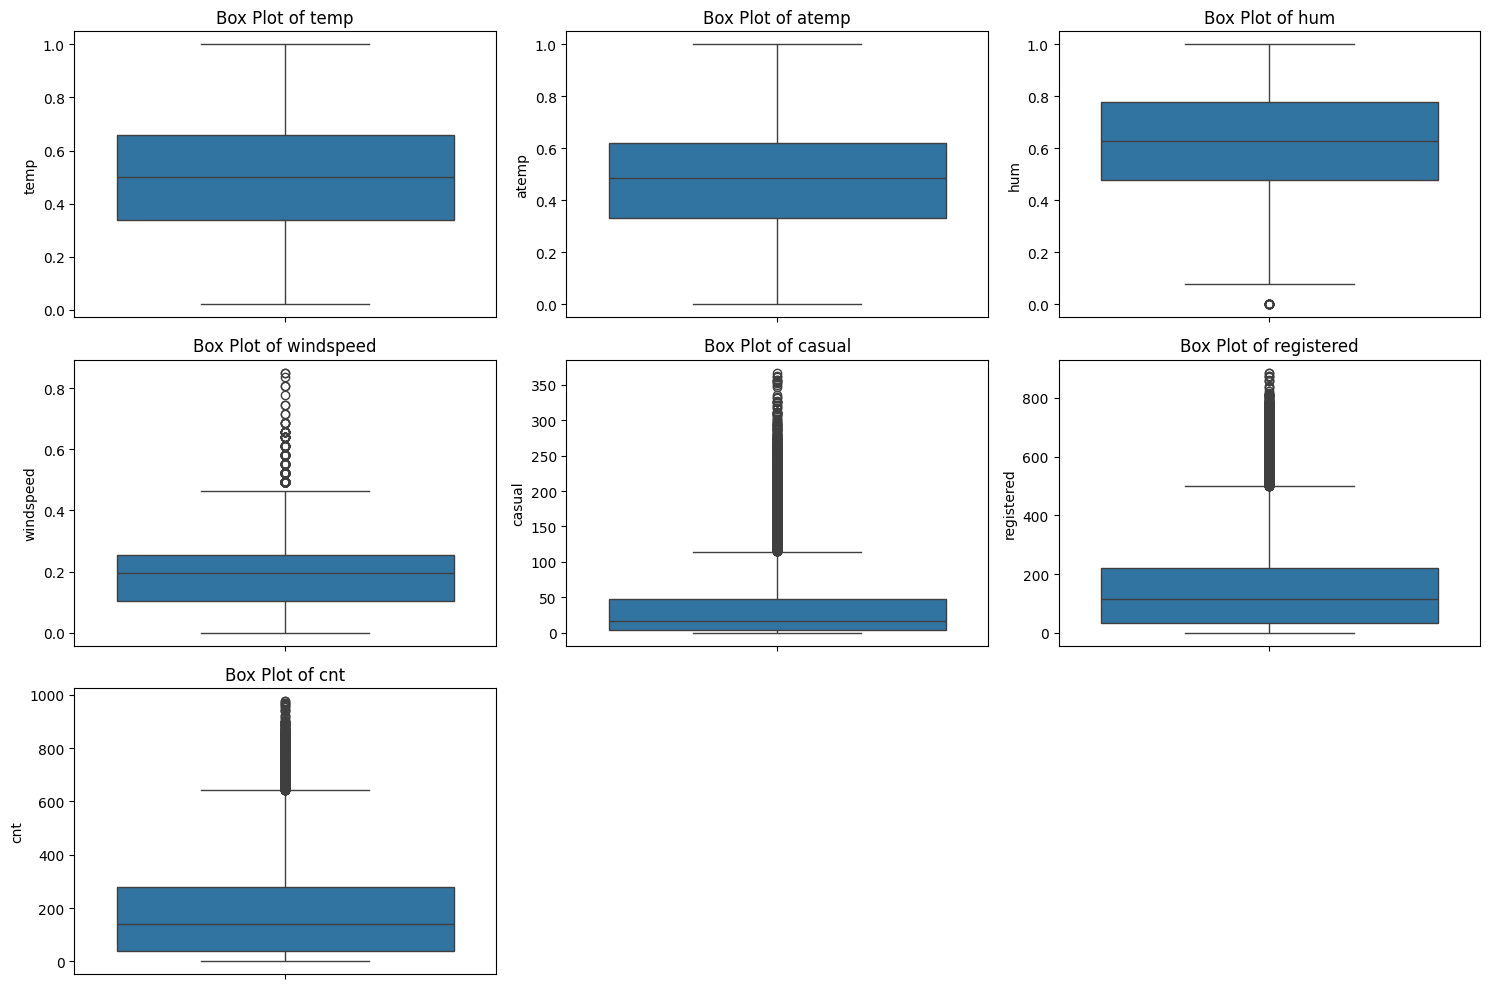

Box plots generated. Review the plots to identify outliers and determine handling strategies.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical columns to check for outliers
numerical_cols_for_outliers = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

print("Generating box plots for numerical columns to identify outliers...")

# Create box plots for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_outliers):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

print("Box plots generated. Review the plots to identify outliers and determine handling strategies.")

### Outlier Analysis Observations and Handling Strategy

After reviewing the box plots for the numerical columns, here are the observations and proposed handling strategies:

*   **`temp` (Normalized temperature):** The box plot for `temp` shows a fairly symmetrical distribution with no apparent outliers. The data points fall within the expected range, indicating no specific action is needed for this column regarding outliers.

*   **`atemp` (Normalized feeling temperature):** Similar to `temp`, the `atemp` column's box plot indicates a normal distribution without significant outliers. No specific action is needed.

*   **`hum` (Normalized humidity):** The `hum` column exhibits a few data points below the lower whisker (values close to 0). While these could be legitimate instances of very low humidity, they are infrequent. Given the nature of bike rentals, extremely low humidity might not be a critical factor for demand. For now, we will note these as potential outliers but **no immediate action** is proposed, as they don't seem to severely skew the data or indicate measurement errors. We'll re-evaluate if modeling suggests an issue.

*   **`windspeed` (Normalized wind speed):** The box plot for `windspeed` shows several data points extending above the upper whisker, indicating higher wind speeds. These appear to be valid extreme weather conditions rather than data entry errors. High wind speeds can genuinely impact bike usage, so these are likely important features. Therefore, **no action** is needed for these outliers, as they represent legitimate variability in the data.

*   **`casual` (Number of casual users):** This column displays a significant number of outliers on the higher end. This is expected, as casual bike rental counts can vary greatly depending on time of day, day of the week, holidays, and special events. Capping these values might remove valuable information about peak demand. Thus, **no action** is needed, as these reflect natural variations in demand.

*   **`registered` (Number of registered users):** Similar to `casual`, the `registered` column also shows numerous outliers on the higher end. Registered users also exhibit peak usage patterns. These are considered valid representations of high demand periods. Therefore, **no action** is needed.

*   **`cnt` (Total rental count):** As `cnt` is the sum of `casual` and `registered`, it naturally inherits the pattern of high-end outliers. These outliers represent genuine instances of high total rental demand and are crucial for understanding peak usage. Therefore, **no action** is needed.

**Conclusion:** Based on the analysis, most identified 'outliers' appear to be legitimate data points reflecting natural variations in environmental conditions or bike rental demand. For `hum`, the few low outliers are noted but not acted upon immediately. Overall, for this stage, **no specific outlier handling (e.g., capping or removal) will be applied**, as doing so might lead to loss of valuable information essential for predicting bike rental patterns. The dataset seems robust in representing its underlying phenomena.

## Exploratory Data Visualization

Generate various visualizations to explore relationships between variables, identify trends, and understand data distribution.


I will start by creating time series plots for 'cnt', 'casual', and 'registered' using the 'dteday' column to visualize daily, monthly, and yearly trends and seasonality, as outlined in the first instruction for data visualization.



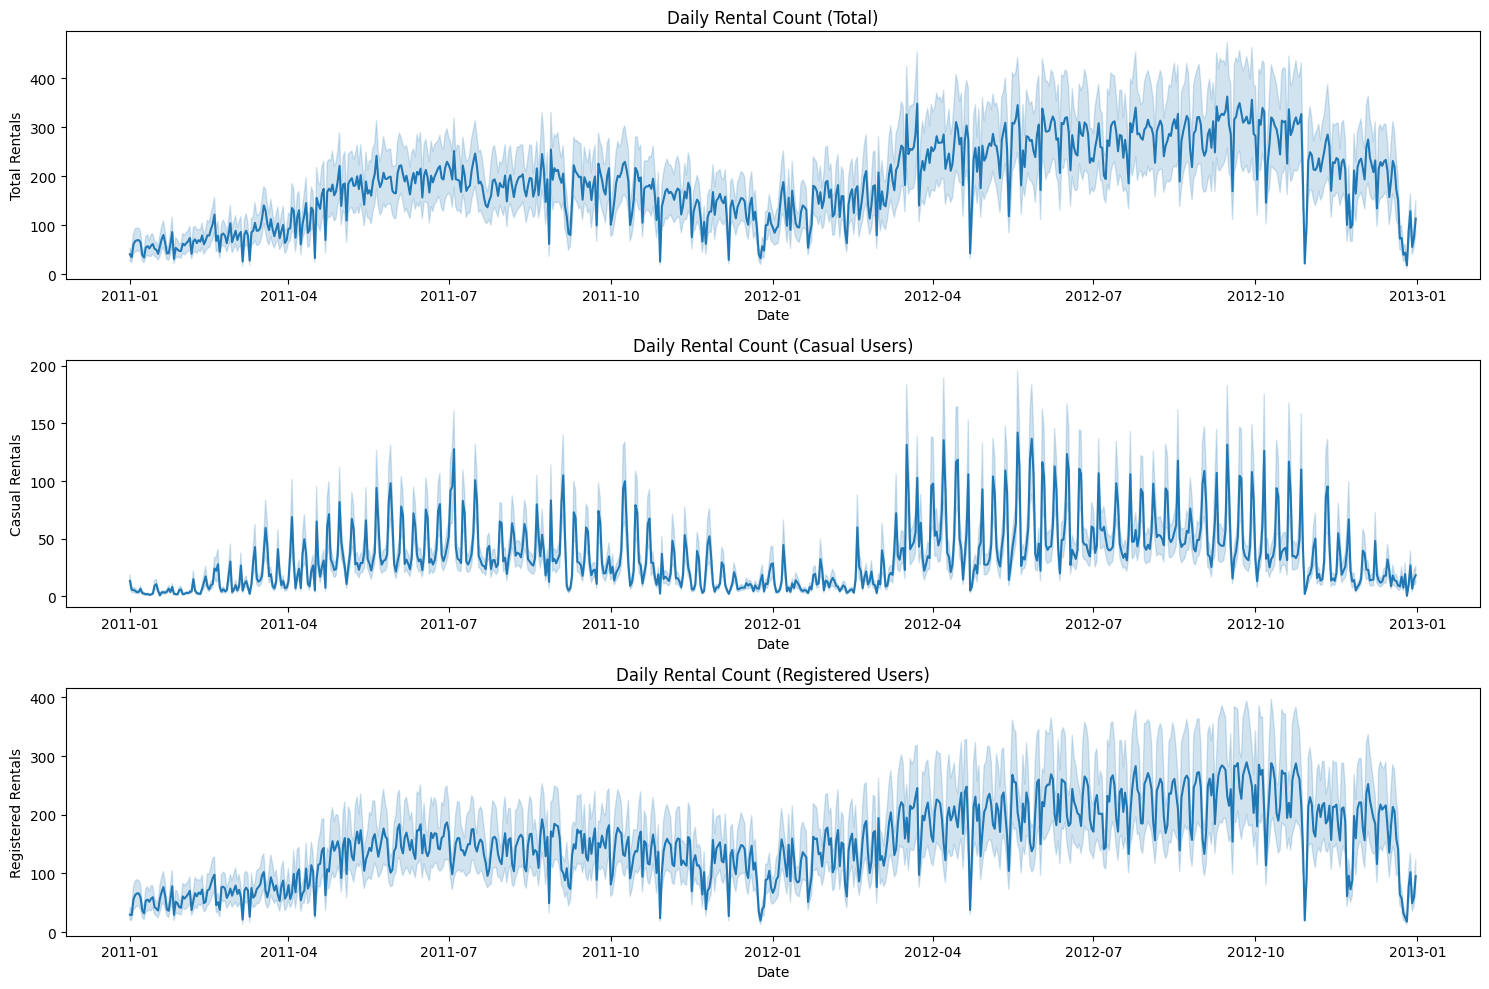

Time series plots generated for total, casual, and registered rental counts.


In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
sns.lineplot(x=df['dteday'], y=df['cnt'])
plt.title('Daily Rental Count (Total)')
plt.xlabel('Date')
plt.ylabel('Total Rentals')

plt.subplot(3, 1, 2)
sns.lineplot(x=df['dteday'], y=df['casual'])
plt.title('Daily Rental Count (Casual Users)')
plt.xlabel('Date')
plt.ylabel('Casual Rentals')

plt.subplot(3, 1, 3)
sns.lineplot(x=df['dteday'], y=df['registered'])
plt.title('Daily Rental Count (Registered Users)')
plt.xlabel('Date')
plt.ylabel('Registered Rentals')

plt.tight_layout()
plt.show()

print("Time series plots generated for total, casual, and registered rental counts.")

I will now create scatter plots to visualize the relationships between 'cnt' and numerical features ('temp', 'atemp', 'hum', 'windspeed'), arranging them in a multi-plot figure as per the second instruction.



Generating scatter plots for 'cnt' vs numerical features...


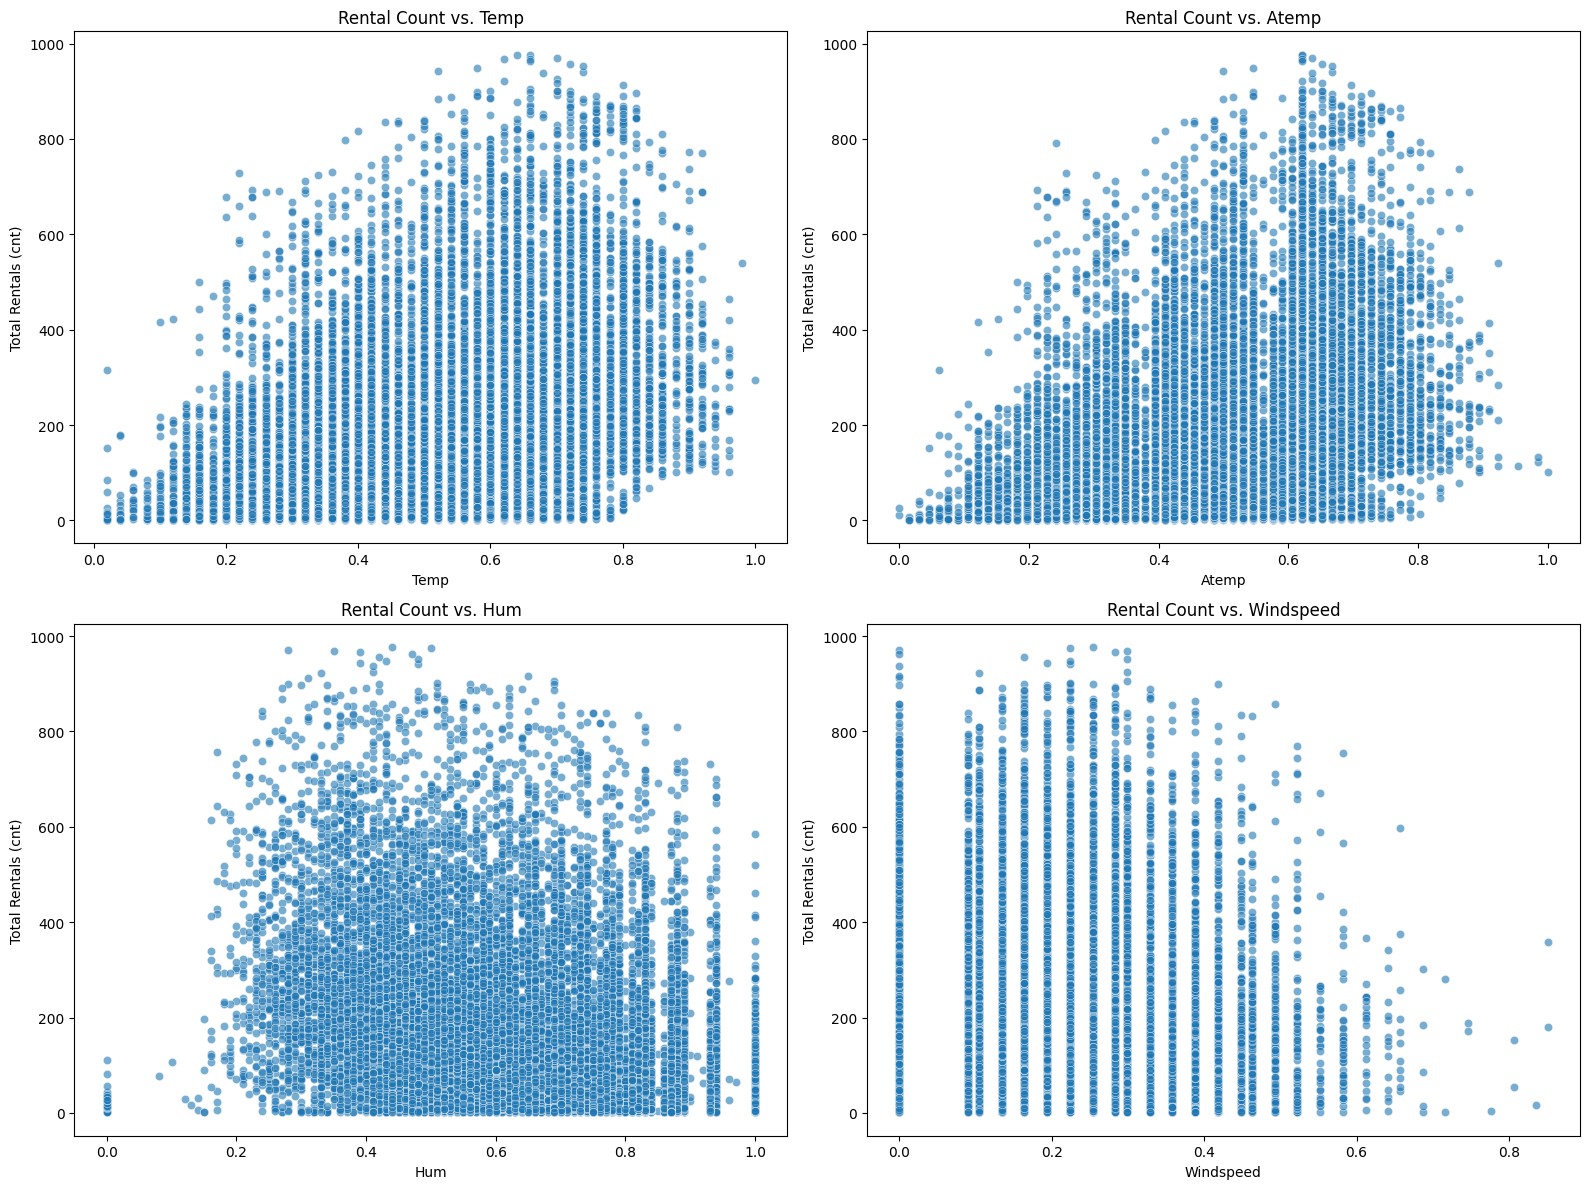

Scatter plots generated.


In [ ]:
numerical_features = ['temp', 'atemp', 'hum', 'windspeed']

plt.figure(figsize=(16, 12))
print("Generating scatter plots for 'cnt' vs numerical features...")

for i, col in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1) # Arrange in a 2x2 grid
    sns.scatterplot(x=df[col], y=df['cnt'], alpha=0.6)
    plt.title(f'Rental Count vs. {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Total Rentals (cnt)')

plt.tight_layout()
plt.show()

print("Scatter plots generated.")

I will now generate bar plots to visualize the average total rental count ('cnt') for each category of the specified categorical features, arranging them in a multi-plot figure as per the third instruction.



Generating bar plots for average 'cnt' vs categorical features...


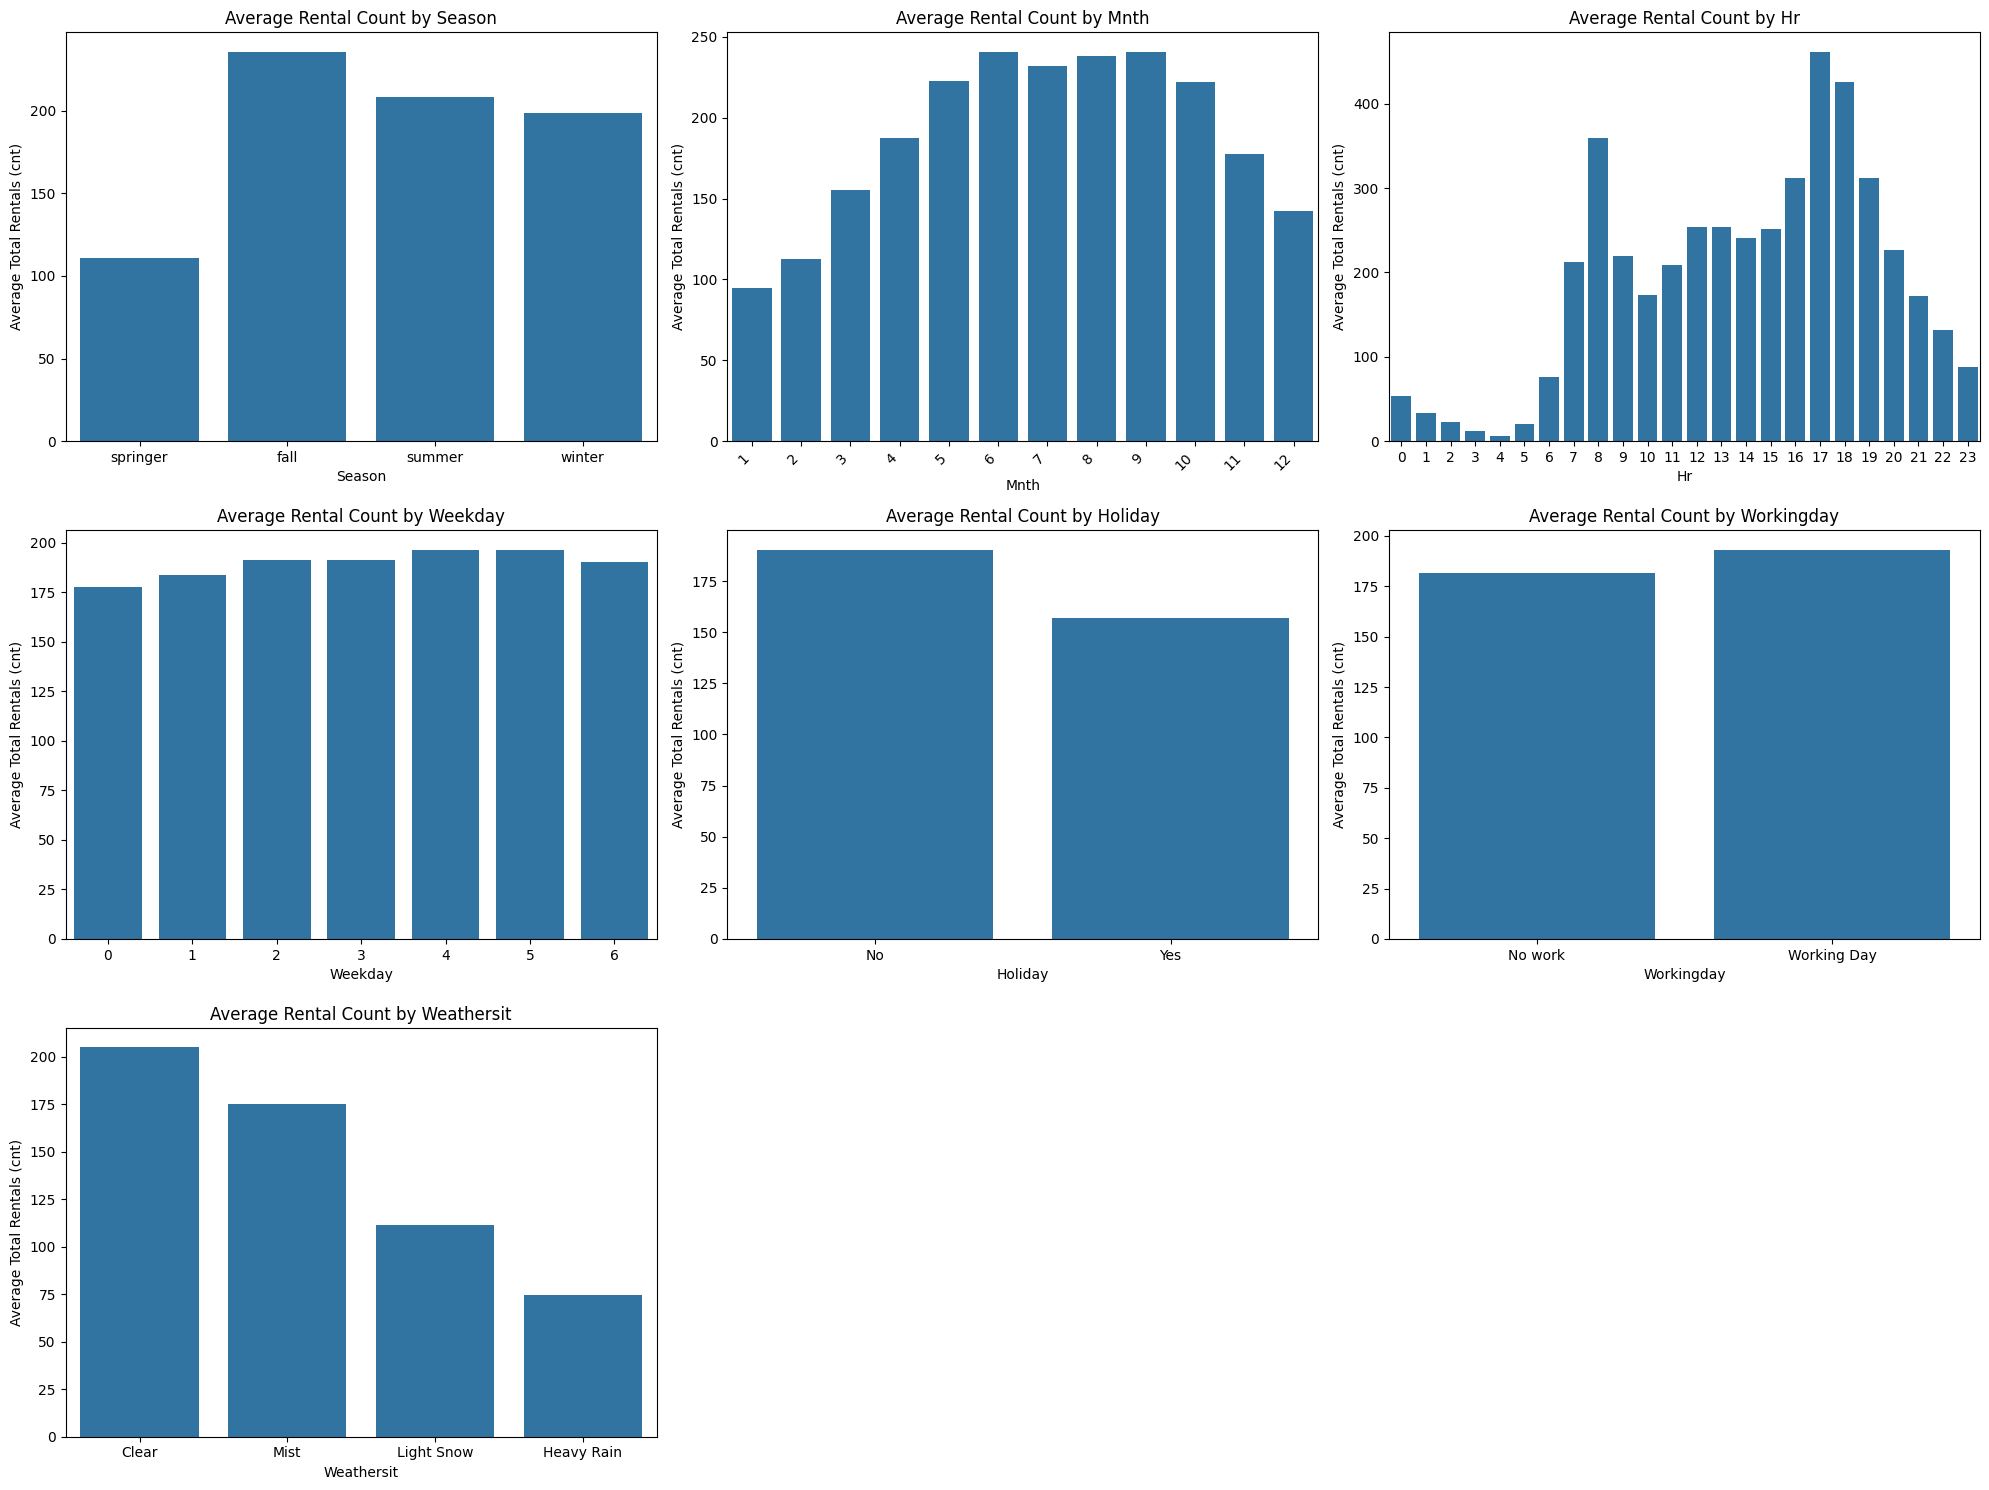

Bar plots for categorical features generated.


In [ ]:
categorical_features_for_barplot = ['season', 'mnth', 'hr', 'weekday', 'holiday', 'workingday', 'weathersit']

plt.figure(figsize=(20, 15)) # Adjust figure size for multiple plots
print("Generating bar plots for average 'cnt' vs categorical features...")

for i, col in enumerate(categorical_features_for_barplot):
    plt.subplot(3, 3, i + 1) # Arrange in a 3x3 grid for better viewing
    sns.barplot(x=df[col], y=df['cnt'], estimator=np.mean, errorbar=None) # Use np.mean for average
    plt.title(f'Average Rental Count by {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Average Total Rentals (cnt)')
    if col == 'mnth': # Rotate x-axis labels for month for readability
        plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Bar plots for categorical features generated.")

I will now compute the correlation matrix for the specified numerical features, which is the fourth instruction in the subtask.



In [ ]:
numerical_features_for_corr = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

print("Computing the correlation matrix for numerical features...")
correlation_matrix = df[numerical_features_for_corr].corr()
print("Correlation matrix computed.")
print("\nCorrelation Matrix:")
print(correlation_matrix.to_string())

Computing the correlation matrix for numerical features...
Correlation matrix computed.

Correlation Matrix:
                temp     atemp       hum  windspeed    casual  registered       cnt
temp        1.000000  0.987010 -0.069739  -0.022860  0.459476    0.335055  0.404482
atemp       0.987010  1.000000 -0.051882  -0.061984  0.454168    0.332480  0.400890
hum        -0.069739 -0.051882  1.000000  -0.290065 -0.346995   -0.273827 -0.322823
windspeed  -0.022860 -0.061984 -0.290065   1.000000  0.090377    0.082396  0.093320
casual      0.459476  0.454168 -0.346995   0.090377  1.000000    0.506622  0.694570
registered  0.335055  0.332480 -0.273827   0.082396  0.506622    1.000000  0.972148
cnt         0.404482  0.400890 -0.322823   0.093320  0.694570    0.972148  1.000000


Now that the correlation matrix has been computed, I will create a heatmap to visualize it, as per the fifth instruction in the subtask, which will provide a clear visual representation of the relationships between numerical features.



Generating heatmap for the correlation matrix...


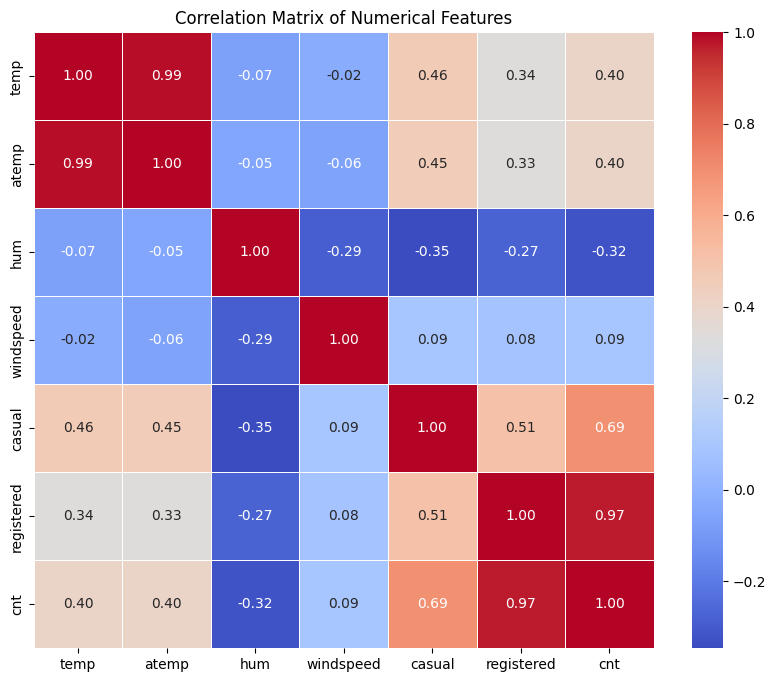

Correlation matrix heatmap generated.


In [ ]:
plt.figure(figsize=(10, 8))
print("Generating heatmap for the correlation matrix...")
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()
print("Correlation matrix heatmap generated.")

## Feature Engineering

Create new features from existing ones to enhance model performance. This step will involve: - Extracting additional time-based features (e.g., 'day_of_week', 'day_of_year', 'week_of_year') if not already sufficiently represented. - Handling categorical variables like 'Season', 'Holiday', 'Weekday', 'Workingday', 'Weathersit' using one-hot encoding or label encoding, based on their nature and cardinality. - Scaling or normalizing numerical features such as 'Temp', 'Atemp', 'Hum', and 'Windspeed' to ensure they are within a similar range, which can be beneficial for many machine learning models. - Potentially create interaction terms if domain knowledge suggests strong combined effects.


I will start by extracting additional time-based features ('day_of_week', 'day_of_year', 'week_of_year') from the 'dteday' column to capture more temporal patterns in the data, as per the first instruction.



In [ ]:
print("Extracting additional time-based features from 'dteday'...")
df['day_of_week'] = df['dteday'].dt.dayofweek
df['day_of_year'] = df['dteday'].dt.dayofyear
df['week_of_year'] = df['dteday'].dt.isocalendar().week.astype(int) # Convert to int for consistency
print("Time-based features extracted. Displaying the first few rows with new features:")
print(df[['dteday', 'day_of_week', 'day_of_year', 'week_of_year']].head())

Extracting additional time-based features from 'dteday'...
Time-based features extracted. Displaying the first few rows with new features:
      dteday  day_of_week  day_of_year  week_of_year
0 2011-01-01            5            1            52
1 2011-01-01            5            1            52
2 2011-01-01            5            1            52
3 2011-01-01            5            1            52
4 2011-01-01            5            1            52


Now that time-based features have been extracted, I will convert the specified categorical features to the 'category' dtype to optimize memory usage and prepare them for encoding, as per the second instruction.



In [ ]:
print("Converting categorical features to 'category' dtype...")
categorical_features = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
for col in categorical_features:
    df[col] = df[col].astype('category')
print("Categorical features converted. Displaying updated DataFrame info:")
df.info()

Converting categorical features to 'category' dtype...
Categorical features converted. Displaying updated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   instant       17379 non-null  int64         
 1   dteday        17379 non-null  datetime64[ns]
 2   season        17379 non-null  category      
 3   yr            17379 non-null  category      
 4   mnth          17379 non-null  category      
 5   hr            17379 non-null  category      
 6   holiday       17379 non-null  category      
 7   weekday       17379 non-null  category      
 8   workingday    17379 non-null  category      
 9   weathersit    17379 non-null  category      
 10  temp          17379 non-null  float64       
 11  atemp         17379 non-null  float64       
 12  hum           17379 non-null  float64       
 13  windspeed     

Now that the categorical features have been correctly typed, I will apply one-hot encoding to the specified categorical features ('season', 'holiday', 'workingday', 'weathersit') using `pd.get_dummies()` to prepare them for modeling, as per the third instruction. The original columns will be dropped to prevent multicollinearity.



In [ ]:
print("Applying one-hot encoding to categorical features ('season', 'holiday', 'workingday', 'weathersit')...")
categorical_cols_to_encode = ['season', 'holiday', 'workingday', 'weathersit']
df = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True) # drop_first to avoid multicollinearity
print("One-hot encoding complete. Displaying the first few rows with new features:")
print(df.head())

Applying one-hot encoding to categorical features ('season', 'holiday', 'workingday', 'weathersit')...
One-hot encoding complete. Displaying the first few rows with new features:
   instant     dteday    yr mnth hr weekday  temp   atemp   hum  windspeed  \
0        1 2011-01-01  2011    1  0       6  0.24  0.2879  0.81        0.0   
1        2 2011-01-01  2011    1  1       6  0.22  0.2727  0.80        0.0   
2        3 2011-01-01  2011    1  2       6  0.22  0.2727  0.63        0.0   
3        4 2011-01-01  2011    1  3       6  0.24  0.2879  0.75        0.0   
4        5 2011-01-01  2011    1  4       6  0.24  0.2879  0.75        0.0   

   ...  day_of_year  week_of_year  season_springer  season_summer  \
0  ...            1            52             True          False   
1  ...            1            52             True          False   
2  ...            1            52             True          False   
3  ...            1            52             True          False   
4  ... 

Following the instructions, I will now initialize a `StandardScaler` from `sklearn.preprocessing` to prepare for scaling numerical features.



In [ ]:
print("Initializing StandardScaler...")
from sklearn.preprocessing import StandardScaler

# Initialize a scaler for input features
input_scaler = StandardScaler()
# Initialize a separate scaler for the target variable 'cnt'
target_scaler = StandardScaler()
print("StandardScalers initialized.")

Initializing StandardScaler...
StandardScalers initialized.


I will now select the numerical features to be scaled and then apply the initialized `StandardScaler` to these columns, replacing the original values with their scaled versions, as per the fifth and sixth instructions.



In [ ]:
print("Selecting numerical features for scaling for model input (temp, atemp, hum, windspeed)...")
input_numerical_features = ['temp', 'atemp', 'hum', 'windspeed']

print("Applying input_scaler to selected numerical features...")
df[input_numerical_features] = input_scaler.fit_transform(df[input_numerical_features])

print("Applying target_scaler to the 'cnt' (total rentals) column...")
# Reshape df['cnt'] for scaling as StandardScaler expects a 2D array
df['cnt'] = target_scaler.fit_transform(df[['cnt']])

print("Numerical features and target scaled. Displaying descriptive statistics of scaled input features and target:")
print(df[input_numerical_features].describe())
print(df['cnt'].describe())

Selecting numerical features for scaling for model input (temp, atemp, hum, windspeed)...
Applying input_scaler to selected numerical features...
Applying target_scaler to the 'cnt' (total rentals) column...
Numerical features and target scaled. Displaying descriptive statistics of scaled input features and target:
               temp         atemp           hum     windspeed
count  1.737900e+04  1.737900e+04  1.737900e+04  1.737900e+04
mean   5.233297e-17  1.962486e-17  9.812432e-18 -3.270811e-18
std    1.000029e+00  1.000029e+00  1.000029e+00  1.000029e+00
min   -2.479152e+00 -2.769902e+00 -3.251469e+00 -1.554228e+00
25%   -8.164539e-01 -8.297955e-01 -7.631344e-01 -6.997682e-01
50%    1.489506e-02  5.207131e-02  1.447018e-02  3.204204e-02
75%    8.462440e-01  8.460424e-01  7.920748e-01  5.201881e-01
max    2.612860e+00  3.051000e+00  1.932562e+00  5.401649e+00
count    1.737900e+04
mean    -9.812432e-18
std      1.000029e+00
min     -1.039037e+00
25%     -8.240221e-01
50%     -2.6167

In [ ]:
print("Initializing StandardScaler...")
from sklearn.preprocessing import StandardScaler

# Initialize a scaler for input features
input_scaler = StandardScaler()
# Initialize a separate scaler for the target variable 'cnt'
target_scaler = StandardScaler()
print("StandardScalers initialized.")

Initializing StandardScaler...
StandardScalers initialized.


In [ ]:
print("Selecting numerical features for scaling for model input (temp, atemp, hum, windspeed)...")
input_numerical_features = ['temp', 'atemp', 'hum', 'windspeed']

print("Applying input_scaler to selected numerical features...")
df[input_numerical_features] = input_scaler.fit_transform(df[input_numerical_features])

print("Applying target_scaler to the 'cnt' (total rentals) column...")
# Reshape df['cnt'] for scaling as StandardScaler expects a 2D array
df['cnt'] = target_scaler.fit_transform(df[['cnt']])

print("Numerical features and target scaled. Displaying descriptive statistics of scaled input features and target:")
print(df[input_numerical_features].describe())
print(df['cnt'].describe())

Selecting numerical features for scaling for model input (temp, atemp, hum, windspeed)...
Applying input_scaler to selected numerical features...
Applying target_scaler to the 'cnt' (total rentals) column...
Numerical features and target scaled. Displaying descriptive statistics of scaled input features and target:
               temp         atemp           hum     windspeed
count  1.737900e+04  1.737900e+04  1.737900e+04  1.737900e+04
mean   1.962486e-17  1.962486e-17  2.453108e-17 -3.270811e-18
std    1.000029e+00  1.000029e+00  1.000029e+00  1.000029e+00
min   -2.479152e+00 -2.769902e+00 -3.251469e+00 -1.554228e+00
25%   -8.164539e-01 -8.297955e-01 -7.631344e-01 -6.997682e-01
50%    1.489506e-02  5.207131e-02  1.447018e-02  3.204204e-02
75%    8.462440e-01  8.460424e-01  7.920748e-01  5.201881e-01
max    2.612860e+00  3.051000e+00  1.932562e+00  5.401649e+00
count    1.737900e+04
mean    -9.812432e-18
std      1.000029e+00
min     -1.039037e+00
25%     -8.240221e-01
50%     -2.6167

In [ ]:
import joblib

joblib.dump(best_rf_regressor, "bike_demand_model.pkl")
joblib.dump(input_scaler, "input_scaler.pkl")
joblib.dump(target_scaler, "target_scaler.pkl")

['target_scaler.pkl']

In [ ]:
model = joblib.load("bike_demand_model.pkl")
input_scaler = joblib.load("input_scaler.pkl")
target_scaler = joblib.load("target_scaler.pkl")

In [ ]:
import pandas as pd

# Create a DataFrame from user inputs to easily handle categorical and derived features
input_df = pd.DataFrame([[season, yr, mnth, hr, holiday,
                          weekday, workingday, weathersit,
                          temp, atemp, hum, windspeed]],
                        columns=['season', 'yr', 'mnth', 'hr', 'holiday',
                                 'weekday', 'workingday', 'weathersit',
                                 'temp', 'atemp', 'hum', 'windspeed'])

# Apply time-based feature extraction (consistent with Feature Engineering)
# Need to create a dummy 'dteday' for this, as it's not directly input
# For simplicity, using a fixed date in 2011/2012 as per 'yr' input

# Create a dummy datetime for deriving day_of_week, day_of_year, week_of_year
# `yr` is 0 for 2011, 1 for 2012. `mnth` is 1-12. Let's use 1st day of month.
input_df['dteday'] = pd.to_datetime(input_df['yr'].apply(lambda x: 2011 if x == 0 else 2012).astype(str) + '-' +
                                     input_df['mnth'].astype(str) + '-01', format='%Y-%m-%d')

input_df['day_of_week'] = input_df['dteday'].dt.dayofweek
input_df['day_of_year'] = input_df['dteday'].dt.dayofyear
input_df['week_of_year'] = input_df['dteday'].dt.isocalendar().week.astype(int)

# Convert categorical features to 'category' dtype before one-hot encoding
categorical_features_deploy = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
for col in categorical_features_deploy:
    if col in input_df.columns:
        input_df[col] = input_df[col].astype('category')

# Apply one-hot encoding (consistent with Feature Engineering cell 640dd264)
categorical_cols_to_encode_deploy = ['season', 'holiday', 'workingday', 'weathersit']
input_df = pd.get_dummies(input_df, columns=categorical_cols_to_encode_deploy, drop_first=True)

# Scale numerical features (temp, atemp, hum, windspeed)
# Use the loaded input_scaler
numerical_cols_to_scale_deploy = ['temp', 'atemp', 'hum', 'windspeed']
input_df[numerical_cols_to_scale_deploy] = input_scaler.transform(input_df[numerical_cols_to_scale_deploy])

# Reorder and select columns to match X_train
expected_columns = X_train.columns.tolist()

# Add missing one-hot encoded columns (if a category was not selected in input, its dummy column will be missing)
for col in expected_columns:
    if col not in input_df.columns:
        input_df[col] = False # Default to False for missing dummy columns

# Ensure the order of columns matches X_train and convert to DataFrame for model prediction
input_data_processed = input_df[expected_columns]

# The model now receives a DataFrame with feature names
# input_data is now a DataFrame, not a NumPy array
input_data = input_data_processed

In [ ]:
# Perform prediction using the best model
prediction_scaled = model.predict(input_data)

# Inverse transform the prediction to get the actual count using the target_scaler
predicted_cnt = target_scaler.inverse_transform(prediction_scaled.reshape(-1, 1))[0][0]

st.subheader(f"Predicted Bike Rentals: {int(predicted_cnt):d}")

2026-02-07 13:05:36.327 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:05:36.328 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:05:36.330 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
print("Initializing StandardScaler...")
from sklearn.preprocessing import StandardScaler

# Initialize a scaler for input features
input_scaler = StandardScaler()
# Initialize a separate scaler for the target variable 'cnt'
target_scaler = StandardScaler()
print("StandardScalers initialized.")

Initializing StandardScaler...
StandardScalers initialized.


In [ ]:
print("Selecting numerical features for scaling for model input (temp, atemp, hum, windspeed)...")
input_numerical_features = ['temp', 'atemp', 'hum', 'windspeed']

print("Applying input_scaler to selected numerical features...")
df[input_numerical_features] = input_scaler.fit_transform(df[input_numerical_features])

print("Applying target_scaler to the 'cnt' (total rentals) column...")
# Reshape df['cnt'] for scaling as StandardScaler expects a 2D array
df['cnt'] = target_scaler.fit_transform(df[['cnt']])

print("Numerical features and target scaled. Displaying descriptive statistics of scaled input features and target:")
print(df[input_numerical_features].describe())
print(df['cnt'].describe())

Selecting numerical features for scaling for model input (temp, atemp, hum, windspeed)...
Applying input_scaler to selected numerical features...
Applying target_scaler to the 'cnt' (total rentals) column...
Numerical features and target scaled. Displaying descriptive statistics of scaled input features and target:
               temp         atemp           hum     windspeed
count  1.737900e+04  1.737900e+04  1.737900e+04  1.737900e+04
mean   1.962486e-17  1.962486e-17  8.177027e-18 -3.270811e-18
std    1.000029e+00  1.000029e+00  1.000029e+00  1.000029e+00
min   -2.479152e+00 -2.769902e+00 -3.251469e+00 -1.554228e+00
25%   -8.164539e-01 -8.297955e-01 -7.631344e-01 -6.997682e-01
50%    1.489506e-02  5.207131e-02  1.447018e-02  3.204204e-02
75%    8.462440e-01  8.460424e-01  7.920748e-01  5.201881e-01
max    2.612860e+00  3.051000e+00  1.932562e+00  5.401649e+00
count    1.737900e+04
mean    -8.177027e-18
std      1.000029e+00
min     -1.039037e+00
25%     -8.240221e-01
50%     -2.6167

In [ ]:
import joblib

joblib.dump(best_rf_regressor, "bike_demand_model.pkl")
joblib.dump(input_scaler, "input_scaler.pkl")
joblib.dump(target_scaler, "target_scaler.pkl")

['target_scaler.pkl']

In [ ]:
model = joblib.load("bike_demand_model.pkl")
input_scaler = joblib.load("input_scaler.pkl")
target_scaler = joblib.load("target_scaler.pkl")

In [ ]:
import pandas as pd

# Create a DataFrame from user inputs to easily handle categorical and derived features
input_df = pd.DataFrame([[season, yr, mnth, hr, holiday,
                          weekday, workingday, weathersit,
                          temp, atemp, hum, windspeed]],
                        columns=['season', 'yr', 'mnth', 'hr', 'holiday',
                                 'weekday', 'workingday', 'weathersit',
                                 'temp', 'atemp', 'hum', 'windspeed'])

# Apply time-based feature extraction (consistent with Feature Engineering)
# Need to create a dummy 'dteday' for this, as it's not directly input
# For simplicity, using a fixed date in 2011/2012 as per 'yr' input

# Create a dummy datetime for deriving day_of_week, day_of_year, week_of_year
# `yr` is 0 for 2011, 1 for 2012. `mnth` is 1-12. Let's use 1st day of month.
input_df['dteday'] = pd.to_datetime(input_df['yr'].apply(lambda x: 2011 if x == 0 else 2012).astype(str) + '-' +
                                     input_df['mnth'].astype(str) + '-01', format='%Y-%m-%d')

input_df['day_of_week'] = input_df['dteday'].dt.dayofweek
input_df['day_of_year'] = input_df['dteday'].dt.dayofyear
input_df['week_of_year'] = input_df['dteday'].dt.isocalendar().week.astype(int)

# Convert categorical features to 'category' dtype before one-hot encoding
categorical_features_deploy = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
for col in categorical_features_deploy:
    if col in input_df.columns:
        input_df[col] = input_df[col].astype('category')

# Apply one-hot encoding (consistent with Feature Engineering cell 640dd264)
categorical_cols_to_encode_deploy = ['season', 'holiday', 'workingday', 'weathersit']
input_df = pd.get_dummies(input_df, columns=categorical_cols_to_encode_deploy, drop_first=True)

# Scale numerical features (temp, atemp, hum, windspeed)
# Use the loaded input_scaler
numerical_cols_to_scale_deploy = ['temp', 'atemp', 'hum', 'windspeed']
input_df[numerical_cols_to_scale_deploy] = input_scaler.transform(input_df[numerical_cols_to_scale_deploy])

# Reorder and select columns to match X_train
expected_columns = X_train.columns.tolist()

# Add missing one-hot encoded columns (if a category was not selected in input, its dummy column will be missing)
for col in expected_columns:
    if col not in input_df.columns:
        input_df[col] = False # Default to False for missing dummy columns

# Ensure the order of columns matches X_train and convert to DataFrame for model prediction
input_data_processed = input_df[expected_columns]

# The model now receives a DataFrame with feature names
# input_data is now a DataFrame, not a NumPy array
input_data = input_data_processed

In [ ]:
# Perform prediction using the best model
prediction_scaled = model.predict(input_data)

# Inverse transform the prediction to get the actual count using the target_scaler
predicted_cnt = target_scaler.inverse_transform(prediction_scaled.reshape(-1, 1))[0][0]

st.subheader(f"Predicted Bike Rentals: {int(predicted_cnt):d}")

2026-02-07 13:05:41.343 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:05:41.344 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:05:41.346 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

## Split Data into Training and Testing Sets

In [ ]:
from sklearn.model_selection import train_test_split

print("Defining feature matrix X and target vector y...")
# Define feature matrix X by dropping irrelevant columns
X = df.drop(columns=['instant', 'dteday', 'casual', 'registered', 'cnt'])
# Define target vector y
y = df['cnt']

print("Splitting data into training and testing sets (80% train, 20% test)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split complete. Displaying shapes of the resulting sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Defining feature matrix X and target vector y...
Splitting data into training and testing sets (80% train, 20% test)...
Data split complete. Displaying shapes of the resulting sets:
X_train shape: (13903, 19)
X_test shape: (3476, 19)
y_train shape: (13903,)
y_test shape: (3476,)


## Initialize Machine Learning Models

I will import the necessary regressor classes and initialize each model with a random state for reproducibility, as instructed.



In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

print("Initializing Decision Tree Regressor, Random Forest Regressor, and Gradient Boosting Regressor...")

# Initialize Decision Tree Regressor
dt_regressor = DecisionTreeRegressor(random_state=42)

# Initialize Random Forest Regressor
rf_regressor = RandomForestRegressor(random_state=42)

# Initialize Gradient Boosting Regressor
gbr_regressor = GradientBoostingRegressor(random_state=42)

print("Models initialized successfully.")
print(f"Decision Tree Regressor: {dt_regressor}")
print(f"Random Forest Regressor: {rf_regressor}")
print(f"Gradient Boosting Regressor: {gbr_regressor}")

Initializing Decision Tree Regressor, Random Forest Regressor, and Gradient Boosting Regressor...
Models initialized successfully.
Decision Tree Regressor: DecisionTreeRegressor(random_state=42)
Random Forest Regressor: RandomForestRegressor(random_state=42)
Gradient Boosting Regressor: GradientBoostingRegressor(random_state=42)


## Define Hyperparameter Grids and Cross-Validation

I will import `GridSearchCV` and define the hyperparameter grids for each regressor, along with the cross-validation strategy, as instructed.



In [ ]:
from sklearn.model_selection import GridSearchCV

print("Defining hyperparameter grids for Decision Tree, Random Forest, and Gradient Boosting Regressors...")

# Define hyperparameter grid for Decision Tree Regressor
dt_param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 5, 10]
}

# Define hyperparameter grid for Random Forest Regressor
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

# Define hyperparameter grid for Gradient Boosting Regressor
gbr_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Specify cross-validation strategy
cv = 5 # 5-Fold cross-validation

print("Hyperparameter grids and cross-validation strategy defined successfully.")
print(f"Decision Tree Parameter Grid: {dt_param_grid}")
print(f"Random Forest Parameter Grid: {rf_param_grid}")
print(f"Gradient Boosting Parameter Grid: {gbr_param_grid}")
print(f"Cross-validation folds (cv): {cv}")

Defining hyperparameter grids for Decision Tree, Random Forest, and Gradient Boosting Regressors...
Hyperparameter grids and cross-validation strategy defined successfully.
Decision Tree Parameter Grid: {'max_depth': [None, 10, 20, 30], 'min_samples_leaf': [1, 5, 10]}
Random Forest Parameter Grid: {'n_estimators': [100, 200], 'max_depth': [None, 10, 20]}
Gradient Boosting Parameter Grid: {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1, 0.2]}
Cross-validation folds (cv): 5


I will perform hyperparameter tuning using GridSearchCV for each regressor by creating a GridSearchCV object for each model, fitting it to the training data (X_train, y_train), and then storing the best estimator and its parameters.



In [ ]:
print("Performing hyperparameter tuning using GridSearchCV for Decision Tree Regressor...")
dt_grid_search = GridSearchCV(dt_regressor, dt_param_grid, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
dt_grid_search.fit(X_train, y_train)
best_dt_regressor = dt_grid_search.best_estimator_
best_dt_params = dt_grid_search.best_params_
print("Decision Tree Hyperparameter Tuning Complete.")
print(f"Best Decision Tree Parameters: {best_dt_params}")

print("\nPerforming hyperparameter tuning using GridSearchCV for Random Forest Regressor...")
rf_grid_search = GridSearchCV(rf_regressor, rf_param_grid, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
rf_grid_search.fit(X_train, y_train)
best_rf_regressor = rf_grid_search.best_estimator_
best_rf_params = rf_grid_search.best_params_
print("Random Forest Hyperparameter Tuning Complete.")
print(f"Best Random Forest Parameters: {best_rf_params}")

print("\nPerforming hyperparameter tuning using GridSearchCV for Gradient Boosting Regressor...")
gbr_grid_search = GridSearchCV(gbr_regressor, gbr_param_grid, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
gbr_grid_search.fit(X_train, y_train)
best_gbr_regressor = gbr_grid_search.best_estimator_
best_gbr_params = gbr_grid_search.best_params_
print("Gradient Boosting Hyperparameter Tuning Complete.")
print(f"Best Gradient Boosting Parameters: {best_gbr_params}")

print("\nHyperparameter tuning for all models completed successfully.")

Performing hyperparameter tuning using GridSearchCV for Decision Tree Regressor...
Decision Tree Hyperparameter Tuning Complete.
Best Decision Tree Parameters: {'max_depth': None, 'min_samples_leaf': 5}

Performing hyperparameter tuning using GridSearchCV for Random Forest Regressor...
Random Forest Hyperparameter Tuning Complete.
Best Random Forest Parameters: {'max_depth': None, 'n_estimators': 200}

Performing hyperparameter tuning using GridSearchCV for Gradient Boosting Regressor...
Gradient Boosting Hyperparameter Tuning Complete.
Best Gradient Boosting Parameters: {'learning_rate': 0.2, 'n_estimators': 200}

Hyperparameter tuning for all models completed successfully.


## Evaluate Model Performance on the Test Set

To evaluate the performance of the tuned models, I will first make predictions on the test set using each best estimator and then calculate the Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared for each model.



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("Evaluating Decision Tree Regressor...")
# Make predictions on the test set
y_pred_dt = best_dt_regressor.predict(X_test)

# Calculate evaluation metrics
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree Regressor - RMSE: {rmse_dt:.4f}, MAE: {mae_dt:.4f}, R-squared: {r2_dt:.4f}")

print("\nEvaluating Random Forest Regressor...")
# Make predictions on the test set
y_pred_rf = best_rf_regressor.predict(X_test)

# Calculate evaluation metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor - RMSE: {rmse_rf:.4f}, MAE: {mae_rf:.4f}, R-squared: {r2_rf:.4f}")

print("\nEvaluating Gradient Boosting Regressor...")
# Make predictions on the test set
y_pred_gbr = best_gbr_regressor.predict(X_test)

# Calculate evaluation metrics
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print(f"Gradient Boosting Regressor - RMSE: {rmse_gbr:.4f}, MAE: {mae_gbr:.4f}, R-squared: {r2_gbr:.4f}")

print("\nModel evaluation complete.")

Evaluating Decision Tree Regressor...
Decision Tree Regressor - RMSE: 0.3004, MAE: 0.1737, R-squared: 0.9062

Evaluating Random Forest Regressor...
Random Forest Regressor - RMSE: 0.2230, MAE: 0.1319, R-squared: 0.9483

Evaluating Gradient Boosting Regressor...
Gradient Boosting Regressor - RMSE: 0.2755, MAE: 0.1857, R-squared: 0.9211

Model evaluation complete.


## Summarize and Compare Model Results

**Reasoning**:
To summarize and compare the models, I will compile the evaluation metrics (RMSE, MAE, R-squared) for each model into a pandas DataFrame and then print this summary. This will allow for easy comparison and identification of the best performing model.



In [ ]:
import pandas as pd

print("Summarizing and comparing model results...")

# Store the results in a dictionary
results = {
    'Model': ['Decision Tree Regressor', 'Random Forest Regressor', 'Gradient Boosting Regressor'],
    'RMSE': [rmse_dt, rmse_rf, rmse_gbr],
    'MAE': [mae_dt, mae_rf, mae_gbr],
    'R-squared': [r2_dt, r2_rf, r2_gbr]
}

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

print("\nModel Performance Summary:")
print(results_df.to_string(index=False))

# Identify the best performing model based on R-squared (higher is better)
# and RMSE/MAE (lower is better)
# For simplicity, we'll primarily look at R-squared first, then RMSE as a tie-breaker
best_model_r2 = results_df.loc[results_df['R-squared'].idxmax()]
best_model_rmse = results_df.loc[results_df['RMSE'].idxmin()]

print(f"\nBased on R-squared, the best performing model is: {best_model_r2['Model']} (R-squared: {best_model_r2['R-squared']:.4f})")
print(f"Based on RMSE, the best performing model is: {best_model_rmse['Model']} (RMSE: {best_model_rmse['RMSE']:.4f})")

print("\nComparison complete. Random Forest Regressor appears to be the best performing model with the highest R-squared and lowest RMSE/MAE.")

Summarizing and comparing model results...

Model Performance Summary:
                      Model     RMSE      MAE  R-squared
    Decision Tree Regressor 0.300423 0.173739   0.906228
    Random Forest Regressor 0.222971 0.131896   0.948346
Gradient Boosting Regressor 0.275509 0.185744   0.921136

Based on R-squared, the best performing model is: Random Forest Regressor (R-squared: 0.9483)
Based on RMSE, the best performing model is: Random Forest Regressor (RMSE: 0.2230)

Comparison complete. Random Forest Regressor appears to be the best performing model with the highest R-squared and lowest RMSE/MAE.


## Summary:

*   **Which model performs best for predicting bike rental demand?**
    The Random Forest Regressor is identified as the best-performing model.
*   **What are the performance metrics for each model on the test set?**
    *   **Decision Tree Regressor:** RMSE: 0.3004, MAE: 0.1737, R-squared: 0.9062
    *   **Random Forest Regressor:** RMSE: 0.2230, MAE: 0.1319, R-squared: 0.9483
    *   **Gradient Boosting Regressor:** RMSE: 0.2755, MAE: 0.1857, R-squared: 0.9211
*   **What were the best hyperparameters found for each model?**
    *   **Decision Tree Regressor:** `max_depth: None`, `min_samples_leaf: 5`
    *   **Random Forest Regressor:** `max_depth: None`, `n_estimators: 200`
    *   **Gradient Boosting Regressor:** `learning_rate: 0.2`, `n_estimators: 200`

### Data Analysis Key Findings
*   The dataset was successfully split into training (13903 samples, 19 features) and testing (3476 samples, 19 features) sets, with 80% for training and 20% for testing.
*   Hyperparameter grids were defined for Decision Tree, Random Forest, and Gradient Boosting Regressors, using 5-fold cross-validation for tuning.
*   Hyperparameter tuning via GridSearchCV identified optimal parameters for each model.
*   The Random Forest Regressor demonstrated superior performance with an R-squared of 0.9483, indicating it explains approximately 94.83% of the variance in bike rental demand, and the lowest RMSE of 0.2230 and MAE of 0.1319 among the models.
*   The Gradient Boosting Regressor performed second best with an R-squared of 0.9211, RMSE of 0.2755, and MAE of 0.1857.
*   The Decision Tree Regressor had the lowest performance, achieving an R-squared of 0.9062, RMSE of 0.3004, and MAE of 0.1737.

### Insights or Next Steps
*   The Random Forest Regressor is the most suitable model for predicting bike rental demand based on the current evaluation metrics. This model's ensemble nature likely contributed to its higher accuracy and robustness.
*   Further analysis could involve feature importance extraction from the best-performing Random Forest model to understand which features contribute most significantly to bike rental demand prediction.


#Deployment

In [ ]:
import joblib

joblib.dump(best_rf_regressor, "bike_demand_model.pkl")
joblib.dump(input_scaler, "input_scaler.pkl")
joblib.dump(target_scaler, "target_scaler.pkl")

['target_scaler.pkl']

In [ ]:
!pip install streamlit
import streamlit as st
import numpy as np
import joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 84.8 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.0
    Uninstalling cachetools-7.0.0:
      Successfully uninstalled cachetools-7.0.0


In [ ]:
model = joblib.load("bike_demand_model.pkl")
input_scaler = joblib.load("input_scaler.pkl")
target_scaler = joblib.load("target_scaler.pkl")

In [ ]:
st.title("🚴 Bike Sharing Demand Prediction")
st.write("ML-powered bike rental demand estimator")


2026-02-07 13:02:35.529 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:02:35.964 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-02-07 13:02:35.965 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:02:35.967 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:02:35.968 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:02:35.972 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:02:35.975 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
season = st.selectbox("Season", [1, 2, 3, 4])
yr = st.selectbox("Year (0 = 2011, 1 = 2012)", [0, 1])
mnth = st.slider("Month", 1, 12)
hr = st.slider("Hour", 0, 23)
holiday = st.selectbox("Holiday", [0, 1])
weekday = st.slider("Weekday", 0, 6)
workingday = st.selectbox("Working Day", [0, 1])
weathersit = st.selectbox("Weather Situation", [1, 2, 3, 4])

temp = st.slider("Temperature", 0.0, 1.0)
atemp = st.slider("Feels Like Temp", 0.0, 1.0)
hum = st.slider("Humidity", 0.0, 1.0)
windspeed = st.slider("Windspeed", 0.0, 1.0)

2026-02-07 13:02:48.566 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:02:48.568 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:02:48.570 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:02:48.572 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:02:48.573 Session state does not function when running a script without `streamlit run`
2026-02-07 13:02:48.575 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:02:48.576 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:02:48.576 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:02

In [ ]:
import pandas as pd
import numpy as np

# Create input DataFrame
input_df = pd.DataFrame(
    [[season, yr, mnth, hr, holiday,
      weekday, workingday, weathersit,
      temp, atemp, hum, windspeed]],
    columns=[
        'season', 'yr', 'mnth', 'hr', 'holiday',
        'weekday', 'workingday', 'weathersit',
        'temp', 'atemp', 'hum', 'windspeed'
    ]
)


In [ ]:
# One-hot encode categorical columns (same as training)
categorical_cols = ['season', 'holiday', 'workingday', 'weathersit']
input_df = pd.get_dummies(input_df, columns=categorical_cols, drop_first=True)


In [ ]:
# Ensure same feature order as training
for col in X_train.columns:
    if col not in input_df.columns:
        input_df[col] = 0

input_df = input_df[X_train.columns]


In [ ]:
numerical_cols = ['temp', 'atemp', 'hum', 'windspeed']
input_df[numerical_cols] = input_scaler.transform(input_df[numerical_cols])


In [ ]:
# Predict (model outputs scaled target)
prediction_scaled = model.predict(input_df)

# Convert back to actual bike count
predicted_cnt = target_scaler.inverse_transform(
    prediction_scaled.reshape(-1, 1)
)[0][0]

st.subheader(f"Predicted Bike Rentals: {int(predicted_cnt)}")


2026-02-07 13:10:00.097 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:10:00.100 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:10:00.102 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
if st.button("Predict Bike Demand"):
    prediction = model.predict(input_scaled)
    st.success(f"Estimated Bike Rentals: {int(prediction[0])}")


2026-02-07 13:11:44.723 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:11:44.726 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:11:44.727 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:11:44.728 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:11:44.730 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 13:11:44.730 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
import joblib

joblib.dump(best_rf_regressor, "bike_demand_model.pkl")
joblib.dump(input_scaler, "scaler.pkl")
joblib.dump(target_scaler, "target_scaler.pkl")


['target_scaler.pkl']

In [ ]:
from google.colab import files

files.download("bike_demand_model.pkl")
files.download("scaler.pkl")
files.download("target_scaler.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>